In [1]:
import os
import glob
import json

import torch
import pandas as pd

from torch.utils.data import Dataset
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformer_lens import HookedTransformer, HookedTransformerConfig

from dictionary_learning import AutoEncoder

from dictionary_learning import utils as dl_utils

from tqdm import tqdm

In [2]:
E = 100
T = 10
SEP = E + T  # 110
Q = E + T + 1  # 111
PAD = E + T + 2  # 112
D_VOCAB = E + T + 3


class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label


dataset = load_dataset("sojup/entity_binding", split="test")
test_df = dataset.to_pandas()
test_dataset = EntityBindingDataset(test_df)

len(test_dataset), test_dataset[0]

(8000,
 (tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
           24, 110, 105,  70, 111]),
  tensor(37)))

In [3]:
REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

d_model = 256
n_ctx = 64
N_LAYERS = 2
HEADS = 2


def build_model(n_layers: int = 2, n_heads: int = 2) -> HookedTransformer:
    d_head = d_model // n_heads
    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(N_LAYERS, HEADS).to(device)
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)
model.cfg.use_attn_result = True
model.eval()

print("Model loaded.")

Moving model to device:  cpu
Model loaded.


In [4]:
REPO_ID = "sojup/entity_binding_test"
FILENAME = "id_to_entity.csv"

id_mapping_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)
id_mapping_df = pd.read_csv(id_mapping_path)
id_to_entity = dict(zip(id_mapping_df["id"], id_mapping_df["name"]))

id_to_entity[100] = "loves"
id_to_entity[101] = "works with"
id_to_entity[102] = "interacts with"
id_to_entity[103] = "lives with"
id_to_entity[104] = "has a grudge against"
id_to_entity[105] = "is interested in"
id_to_entity[106] = "plays with"
id_to_entity[107] = "goes to school with"
id_to_entity[108] = "is jealous of"
id_to_entity[109] = "wants"

id_to_entity_rev = {v: k for k, v in id_to_entity.items()}


In [5]:
def load_autoencoder(ckpt_path: str, device=device):
    print("Loading SAE from:", ckpt_path)


    ae, cfg = dl_utils.load_dictionary(ckpt_path, device=device)
    ae.eval()
    return ae, cfg


In [6]:
sae, sae_cfg = load_autoencoder("b0_hookz_h0_sep_sweep_d1024_k8_1M", device=device)

Loading SAE from: b0_hookz_h0_sep_sweep_d1024_k8_1M


In [7]:
sae

BatchTopKSAE(
  (decoder): Linear(in_features=1024, out_features=128, bias=False)
  (encoder): Linear(in_features=128, out_features=1024, bias=True)
)

In [8]:
def render_tokens(tokens):
    return [id_to_entity[int(tok)] for tok in tokens]


def extract_facts(tokens):
    facts = []
    comma_positions = (tokens == SEP).nonzero(as_tuple=False).flatten().tolist()
    q_pos = (tokens == Q).nonzero(as_tuple=False).flatten().tolist()
    assert len(q_pos) == 1
    q_pos = q_pos[0]

    query_t = int(tokens[q_pos - 2].item())
    query_e1 = int(tokens[q_pos - 1].item())

    for slot_idx, p in enumerate(comma_positions):
        fact = {
            "slot_idx": slot_idx,
            "comma_pos": p,
            "e1": int(tokens[p - 3].item()),
            "t": int(tokens[p - 2].item()),
            "e2": int(tokens[p - 1].item()),
        }
        fact["matches_query"] = fact["e1"] == query_e1 and fact["t"] == query_t
        facts.append(fact)

    query = {"query_e1": query_e1, "query_t": query_t}
    return facts, query


def pretty_print_example(tokens, label):
    facts, query = extract_facts(tokens)

    print("Prompt:")
    print(" ".join(render_tokens(tokens)))
    print()
    print("Facts:")
    for fact in facts:
        mark = " <-- target fact" if fact["matches_query"] else ""
        print(
            f"[{fact['slot_idx']}] "
            f"{id_to_entity[fact['e1']]} | "
            f"{id_to_entity[fact['t']]} | "
            f"{id_to_entity[fact['e2']]} "
            f"(comma pos {fact['comma_pos']}){mark}"
        )
    print()
    print("Query:")
    print(id_to_entity[query["query_t"]], id_to_entity[query["query_e1"]], "?")
    print("Correct label:", id_to_entity[int(label.item())])


In [9]:
example_idx = 0
tokens, label = test_dataset[example_idx]
pretty_print_example(tokens, label)


Prompt:
Jeffery has a grudge against Angel , Linda lives with Lindsay , Jason is interested in Christine , Lindsay loves Susan , is interested in Jason ?

Facts:
[0] Jeffery | has a grudge against | Angel (comma pos 3)
[1] Linda | lives with | Lindsay (comma pos 7)
[2] Jason | is interested in | Christine (comma pos 11) <-- target fact
[3] Lindsay | loves | Susan (comma pos 15)

Query:
is interested in Jason ?
Correct label: Christine


In [11]:
with torch.no_grad():
    _, cache = model.run_with_cache(tokens, names_filter=["blocks.0.attn.hook_z"])


In [12]:
hook_z = cache["blocks.0.attn.hook_z"][0]  # [seq, n_heads, d_head]

facts, query = extract_facts(tokens)
comma_positions = [f["comma_pos"] for f in facts]

comma_acts = hook_z[comma_positions, 0, :]  # [n_facts, 128]
sae_feats = sae.encode(comma_acts).detach().cpu()


In [18]:
sae_feats.shape

torch.Size([4, 1024])

In [14]:
def show_top_features_per_fact(sae_feats, facts, topk=10, min_val=1e-6):
    for row, fact in enumerate(facts):
        vals, idxs = torch.topk(sae_feats[row], topk)
        print(
            f"\nFact [{fact['slot_idx']}] "
            f"{id_to_entity[fact['e1']]} | {id_to_entity[fact['t']]} | {id_to_entity[fact['e2']]}"
            + (" <-- target" if fact["matches_query"] else "")
        )
        for feat_idx, val in zip(idxs.tolist(), vals.tolist()):
            if val <= min_val:
                continue
            print(f"  feature {feat_idx:4d}: {val:.4f}")


show_top_features_per_fact(sae_feats, facts, topk=12)



Fact [0] Jeffery | has a grudge against | Angel
  feature  794: 0.1236
  feature  626: 0.1052
  feature  454: 0.0165
  feature  548: 0.0050
  feature  373: 0.0028
  feature   88: 0.0017

Fact [1] Linda | lives with | Lindsay
  feature  364: 0.1480
  feature  249: 0.0831
  feature  779: 0.0667
  feature  950: 0.0175
  feature  626: 0.0110
  feature  454: 0.0094
  feature  373: 0.0021
  feature  794: 0.0014

Fact [2] Jason | is interested in | Christine <-- target
  feature  305: 0.1128
  feature  272: 0.0447
  feature  714: 0.0422
  feature  981: 0.0370
  feature  587: 0.0201
  feature   88: 0.0197
  feature  950: 0.0090
  feature  249: 0.0071
  feature  894: 0.0025
  feature  794: 0.0018

Fact [3] Lindsay | loves | Susan
  feature  950: 0.0966
  feature  822: 0.0558
  feature  626: 0.0304
  feature  343: 0.0122
  feature  587: 0.0094
  feature  856: 0.0027
  feature  794: 0.0015


In [16]:
@torch.no_grad()
def collect_hookz_h0_sae_rows(model, sae, test_dataset):
    rows = []

    for dataset_idx in tqdm(range(len(test_dataset))):
        tokens, label = test_dataset[dataset_idx]

        _, cache = model.run_with_cache(
            tokens,
            names_filter=["blocks.0.attn.hook_z"],
        )

        hook_z = cache["blocks.0.attn.hook_z"][0]  # [seq, n_heads, d_head]

        comma_positions = (tokens == SEP).nonzero(as_tuple=False).flatten().tolist()
        if len(comma_positions) == 0:
            continue

        comma_acts = hook_z[comma_positions, 0, :]  # [n_facts, 128]
        sae_feats = sae.encode(comma_acts).detach().cpu()

        q_pos = (tokens == Q).nonzero(as_tuple=False).flatten().tolist()
        assert len(q_pos) == 1
        q_pos = q_pos[0]

        query_t = int(tokens[q_pos - 2].item())
        query_e1 = int(tokens[q_pos - 1].item())

        for slot_idx, p in enumerate(comma_positions):
            e1 = int(tokens[p - 3].item())
            t = int(tokens[p - 2].item())
            e2 = int(tokens[p - 1].item())

            rows.append(
                {
                    "dataset_idx": dataset_idx,
                    "slot_idx": slot_idx,
                    "comma_pos": p,
                    "e1": e1,
                    "t": t,
                    "t_rel": t - E,
                    "e2": e2,
                    "addr": (e1, t),
                    "addr_idx": e1 * T + (t - E),
                    "matches_query": (e1 == query_e1 and t == query_t),
                    "is_correct_fact": (
                        e2 == int(label.item()) and e1 == query_e1 and t == query_t
                    ),
                    "features": sae_feats[slot_idx].clone(),
                }
            )

    return rows


In [17]:
rows = collect_hookz_h0_sae_rows(model, sae, test_dataset)
len(rows)

100%|██████████| 8000/8000 [00:58<00:00, 135.72it/s]


47762

In [18]:
feature_matrix = torch.stack([row["features"] for row in rows], dim=0)  # [N_rows, d_sae]

e1_labels = torch.tensor([row["e1"] for row in rows], dtype=torch.long)
t_labels = torch.tensor([row["t_rel"] for row in rows], dtype=torch.long)  # 0..9
e2_labels = torch.tensor([row["e2"] for row in rows], dtype=torch.long)
addr_labels = torch.tensor([row["addr_idx"] for row in rows], dtype=torch.long)  # 0..999

feature_matrix.shape


torch.Size([47762, 1024])

In [19]:
import matplotlib.pyplot as plt

feature_firing_count = (feature_matrix > 0).sum(dim=0).cpu()  # [d_sae]

print("Total features:", feature_firing_count.numel())
print("Dead features:", (feature_firing_count == 0).sum().item())
print("Live features:", (feature_firing_count > 0).sum().item())
print("Max firing count:", feature_firing_count.max().item())


Total features: 1024
Dead features: 842
Live features: 182
Max firing count: 24673


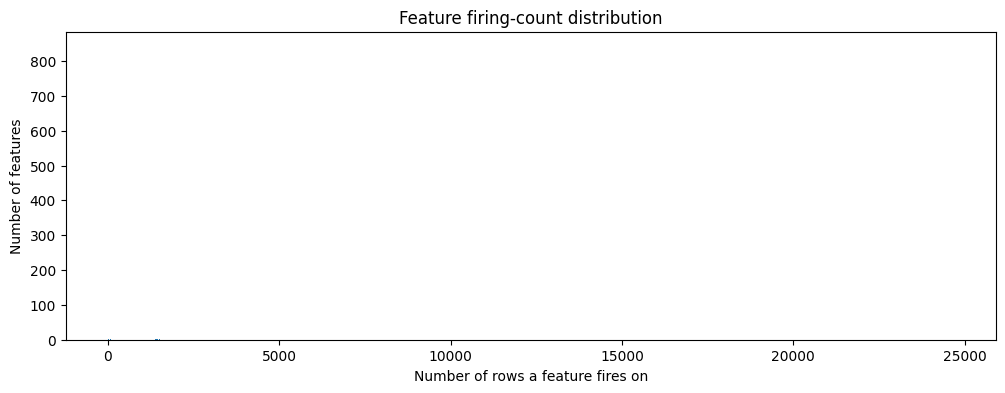

In [20]:
import matplotlib.pyplot as plt

feature_firing_count = (feature_matrix > 0).sum(dim=0)
counts = torch.bincount(feature_firing_count)

plt.figure(figsize=(12, 4))
plt.bar(range(len(counts)), counts.numpy())
plt.xlabel("Number of rows a feature fires on")
plt.ylabel("Number of features")
plt.title("Feature firing-count distribution")
plt.show()


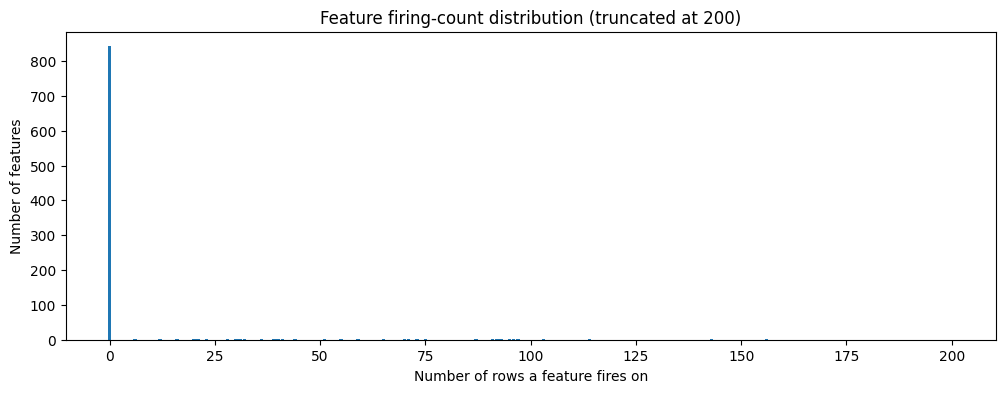

In [21]:
max_x = min(200, int(feature_firing_count.max().item()))

counts = torch.bincount(feature_firing_count, minlength=max_x + 1)

plt.figure(figsize=(12, 4))
plt.bar(range(max_x + 1), counts[: max_x + 1].numpy())
plt.xlabel("Number of rows a feature fires on")
plt.ylabel("Number of features")
plt.title(f"Feature firing-count distribution (truncated at {max_x})")
plt.show()


In [22]:
print("Features firing > 200 rows:", (feature_firing_count > 200).sum().item())
print("Features firing > 1000 rows:", (feature_firing_count > 1000).sum().item())


Features firing > 200 rows: 145
Features firing > 1000 rows: 119


In [23]:
feature_firing_count = (feature_matrix > 0).sum(dim=0).cpu()
feature_total_mass = feature_matrix.sum(dim=0).cpu()

live_features = (feature_firing_count > 0).nonzero(as_tuple=False).flatten()
nontrivial_live_features = (feature_firing_count > 10).nonzero(as_tuple=False).flatten()

print("Total features:", feature_matrix.shape[1])
print("Dead features:", int((feature_firing_count == 0).sum().item()))
print("Live features:", int(live_features.numel()))
print("Nontrivial live features (>10 firings):", int(nontrivial_live_features.numel()))
print()

print("Top 10 features by firing count:")
top_fire_vals, top_fire_idx = torch.topk(feature_firing_count, 10)
for feat_idx, count in zip(top_fire_idx.tolist(), top_fire_vals.tolist()):
    print(f"  feature {feat_idx:4d}: fires on {count} rows")

print()
print("Top 10 features by total activation mass:")
top_mass_vals, top_mass_idx = torch.topk(feature_total_mass, 10)
for feat_idx, mass in zip(top_mass_idx.tolist(), top_mass_vals.tolist()):
    print(f"  feature {feat_idx:4d}: total mass {mass:.4f}")


Total features: 1024
Dead features: 842
Live features: 182
Nontrivial live features (>10 firings): 181

Top 10 features by firing count:
  feature   88: fires on 24673 rows
  feature  981: fires on 20099 rows
  feature  894: fires on 19962 rows
  feature  373: fires on 16354 rows
  feature  249: fires on 15279 rows
  feature  856: fires on 15059 rows
  feature 1002: fires on 14782 rows
  feature  626: fires on 14399 rows
  feature  272: fires on 14378 rows
  feature  128: fires on 12406 rows

Top 10 features by total activation mass:
  feature   88: total mass 873.2112
  feature  981: total mass 757.8459
  feature  894: total mass 747.3680
  feature  373: total mass 646.3475
  feature  626: total mass 591.7072
  feature 1002: total mass 579.4070
  feature  249: total mass 573.7786
  feature  856: total mass 573.7261
  feature  128: total mass 562.8954
  feature  272: total mass 511.9566


In [24]:
num_features = feature_matrix.shape[1]

mass_by_e1 = torch.zeros(num_features, E)
mass_by_t = torch.zeros(num_features, T)
mass_by_e2 = torch.zeros(num_features, E)
mass_by_addr = torch.zeros(num_features, E * T)

for i in tqdm(range(feature_matrix.shape[0])):
    feat_vals = feature_matrix[i]  # [d_sae]

    mass_by_e1[:, e1_labels[i]] += feat_vals
    mass_by_t[:, t_labels[i]] += feat_vals
    mass_by_e2[:, e2_labels[i]] += feat_vals
    mass_by_addr[:, addr_labels[i]] += feat_vals


100%|██████████| 47762/47762 [00:02<00:00, 17849.44it/s]


In [25]:
summary_rows = []

for feat_idx in live_features.tolist():
    total_mass = float(feature_total_mass[feat_idx].item())
    firing_count = int(feature_firing_count[feat_idx].item())
    firing_rate = firing_count / feature_matrix.shape[0]

    mean_when_fired = total_mass / firing_count if firing_count > 0 else 0.0
    max_activation = float(feature_matrix[:, feat_idx].max().item())

    e1_mass = mass_by_e1[feat_idx]
    t_mass = mass_by_t[feat_idx]
    e2_mass = mass_by_e2[feat_idx]
    addr_mass = mass_by_addr[feat_idx]

    top_e1 = int(e1_mass.argmax().item())
    top_t = int(t_mass.argmax().item())
    top_e2 = int(e2_mass.argmax().item())
    top_addr = int(addr_mass.argmax().item())

    top_addr_e1 = top_addr // T
    top_addr_t_rel = top_addr % T
    top_addr_t = top_addr_t_rel + E

    summary_rows.append(
        {
            "feature_idx": feat_idx,
            "firing_count": firing_count,
            "firing_rate": firing_rate,
            "total_mass": total_mass,
            "mean_when_fired": mean_when_fired,
            "max_activation": max_activation,
            "top_e1": top_e1,
            "top_e1_name": id_to_entity[top_e1],
            "top_e1_share": float(e1_mass[top_e1].item() / total_mass),
            "top_t": top_t,
            "top_t_name": id_to_entity[top_t + E],
            "top_t_share": float(t_mass[top_t].item() / total_mass),
            "top_e2": top_e2,
            "top_e2_name": id_to_entity[top_e2],
            "top_e2_share": float(e2_mass[top_e2].item() / total_mass),
            "top_addr_idx": top_addr,
            "top_addr_e1": top_addr_e1,
            "top_addr_t": top_addr_t,
            "top_addr_name": f"{id_to_entity[top_addr_e1]} | {id_to_entity[top_addr_t]}",
            "top_addr_share": float(addr_mass[top_addr].item() / total_mass),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.head()


,feature_idx,firing_count,firing_rate,total_mass,mean_when_fired,max_activation,top_e1,top_e1_name,top_e1_share,top_t,top_t_name,top_t_share,top_e2,top_e2_name,top_e2_share,top_addr_idx,top_addr_e1,top_addr_t,top_addr_name,top_addr_share
0,15,1446,0.030275,61.550564,0.042566,0.120354,38,Michelle,0.815014,6,plays with,0.122677,38,Michelle,0.123683,386,38,106,Michelle | plays with,0.101888
1,16,1547,0.032390,52.377583,0.033858,0.098022,63,Gabrielle,0.809656,7,goes to school with,0.129768,63,Gabrielle,0.125793,637,63,107,Gabrielle | goes to school with,0.105280
2,25,1475,0.030882,66.785355,0.045278,0.122081,49,Michael,0.798846,3,lives with,0.122092,49,Michael,0.137883,493,49,103,Michael | lives with,0.102599
3,29,520,0.010887,3.604149,0.006931,0.012394,93,Robert,0.939589,7,goes to school with,0.113850,95,Patrick,0.021296,937,93,107,Robert | goes to school with,0.107408
4,32,459,0.009610,3.394803,0.007396,0.013488,0,Danielle,0.997265,5,is interested in,0.126614,74,Diana,0.025983,5,0,105,Danielle | is interested in,0.126614


In [26]:
cols_to_show = [
    "feature_idx",
    "firing_count",
    "total_mass",
    "max_activation",
    "top_e1_name",
    "top_e1_share",
    "top_t_name",
    "top_t_share",
    "top_e2_name",
    "top_e2_share",
    "top_addr_name",
    "top_addr_share",
]

print("Top address-selective features")
display(summary_df.sort_values("top_addr_share", ascending=False)[cols_to_show].head(20))

print("Top E2-selective features")
display(summary_df.sort_values("top_e2_share", ascending=False)[cols_to_show].head(20))

print("Top E1-selective features")
display(summary_df.sort_values("top_e1_share", ascending=False)[cols_to_show].head(20))

print("Top T-selective features")
display(summary_df.sort_values("top_t_share", ascending=False)[cols_to_show].head(20))


Top address-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
149,860,6,0.019360,0.004733,Bryan,0.883528,plays with,0.463919,Helen,0.463919,Bryan | plays with,0.463919
179,1008,21,0.113077,0.016077,Whitney,0.650277,lives with,0.322238,Whitney,0.349723,Whitney | lives with,0.279602
11,66,16,0.099133,0.014427,Mitchell,0.789082,has a grudge against,0.266727,Brandon,0.380233,Mitchell | has a grudge against,0.266727
13,70,12,0.065005,0.014752,Leonard,0.903622,is interested in,0.255939,Christopher,0.226933,Leonard | is interested in,0.255939
50,262,20,0.107656,0.011419,Antonio,1.000000,goes to school with,0.253252,Courtney,0.270350,Antonio | goes to school with,0.253252
121,694,32,0.236796,0.018564,Janet,0.991461,interacts with,0.238492,Sherri,0.295021,Janet | interacts with,0.238492
27,122,30,0.165317,0.010200,Susan,0.990724,is jealous of,0.230174,Michelle,0.448492,Susan | is jealous of,0.230174
62,318,44,0.360132,0.022518,Jeffery,0.637865,lives with,0.310608,Veronica,0.310074,Jeffery | lives with,0.218167
72,353,23,0.116474,0.012167,Megan,0.707914,is jealous of,0.289803,Frank,0.383947,Frank | is jealous of,0.206407
96,529,41,0.267204,0.018523,Anna,0.692681,interacts with,0.227281,Robin,0.371719,Anna | interacts with,0.200074


Top E2-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
9,59,28,0.195647,0.018376,Janet,0.803994,works with,0.223600,Andrea,0.482479,Janet | works with,0.194016
86,464,41,0.198744,0.015289,Christopher,0.835529,interacts with,0.205715,John,0.472517,Christopher | interacts with,0.156071
149,860,6,0.019360,0.004733,Bryan,0.883528,plays with,0.463919,Helen,0.463919,Bryan | plays with,0.463919
27,122,30,0.165317,0.010200,Susan,0.990724,is jealous of,0.230174,Michelle,0.448492,Susan | is jealous of,0.230174
72,353,23,0.116474,0.012167,Megan,0.707914,is jealous of,0.289803,Frank,0.383947,Frank | is jealous of,0.206407
11,66,16,0.099133,0.014427,Mitchell,0.789082,has a grudge against,0.266727,Brandon,0.380233,Mitchell | has a grudge against,0.266727
96,529,41,0.267204,0.018523,Anna,0.692681,interacts with,0.227281,Robin,0.371719,Anna | interacts with,0.200074
158,882,36,0.322075,0.024696,Leonard,0.550380,lives with,0.181971,Veronica,0.362747,Veronica | plays with,0.119487
179,1008,21,0.113077,0.016077,Whitney,0.650277,lives with,0.322238,Whitney,0.349723,Whitney | lives with,0.279602
74,358,55,0.335983,0.020456,Sherri,0.506968,works with,0.179244,Sherri,0.341053,Sherri | works with,0.114094


Top E1-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
50,262,20,0.107656,0.011419,Antonio,1.000000,goes to school with,0.253252,Courtney,0.270350,Antonio | goes to school with,0.253252
144,833,462,5.612154,0.020541,Reginald,0.999232,wants,0.120316,Joseph,0.028681,Reginald | wants,0.120316
4,32,459,3.394803,0.013488,Danielle,0.997265,is interested in,0.126614,Diana,0.025983,Danielle | is interested in,0.126614
121,694,32,0.236796,0.018564,Janet,0.991461,interacts with,0.238492,Sherri,0.295021,Janet | interacts with,0.238492
27,122,30,0.165317,0.010200,Susan,0.990724,is jealous of,0.230174,Michelle,0.448492,Susan | is jealous of,0.230174
132,774,465,3.087798,0.012109,Brandon,0.988410,has a grudge against,0.117772,Wendy,0.026175,Brandon | has a grudge against,0.117772
116,669,480,2.331833,0.009040,Eric,0.986296,interacts with,0.124285,Jeremy,0.026823,Eric | interacts with,0.123450
66,329,506,6.923265,0.019257,Reginald,0.980278,wants,0.118827,Andrea,0.021189,Reginald | wants,0.117137
94,513,470,2.256171,0.011612,Michelle,0.961007,is jealous of,0.114203,Jesse,0.026579,Michelle | is interested in,0.104728
174,995,515,2.074178,0.009447,Michael,0.948862,lives with,0.123396,Rachael,0.028691,Michael | lives with,0.117386


Top T-selective features


,feature_idx,firing_count,total_mass,max_activation,top_e1_name,top_e1_share,top_t_name,top_t_share,top_e2_name,top_e2_share,top_addr_name,top_addr_share
101,552,4823,191.404541,0.052037,Christopher,0.014145,wants,1.000001,Diana,0.013033,Christopher | wants,0.014145
125,714,4742,216.134903,0.059604,Bryan,0.014684,is interested in,1.000000,Anthony,0.014079,Bryan | is interested in,0.014684
133,779,4776,327.172607,0.089637,Jesse,0.014115,lives with,1.000000,Bryan,0.014792,Jesse | lives with,0.014115
141,822,4746,314.657043,0.087487,Tasha,0.014379,loves,0.999858,Jeffrey,0.013753,Tasha | loves,0.014375
59,309,4824,321.511932,0.086048,Robert,0.013278,works with,0.999736,Nicholas,0.013709,Robert | works with,0.013273
41,211,4810,318.678619,0.087522,Noah,0.014477,interacts with,0.999721,Christopher,0.013834,Noah | interacts with,0.014477
138,796,832,4.027367,0.006676,Jason,0.022381,is jealous of,0.999627,Jill,0.019559,Jason | is jealous of,0.022381
99,548,11545,235.067047,0.058939,Gabrielle,0.013934,goes to school with,0.872841,Gabrielle,0.012674,Gabrielle | goes to school with,0.012648
28,128,12406,562.895386,0.160242,Allison,0.041205,goes to school with,0.808632,Allison,0.015479,Gabrielle | goes to school with,0.015186
112,626,14399,591.707214,0.160883,Angel,0.039788,has a grudge against,0.770001,Angel,0.013911,Angel | has a grudge against,0.012422


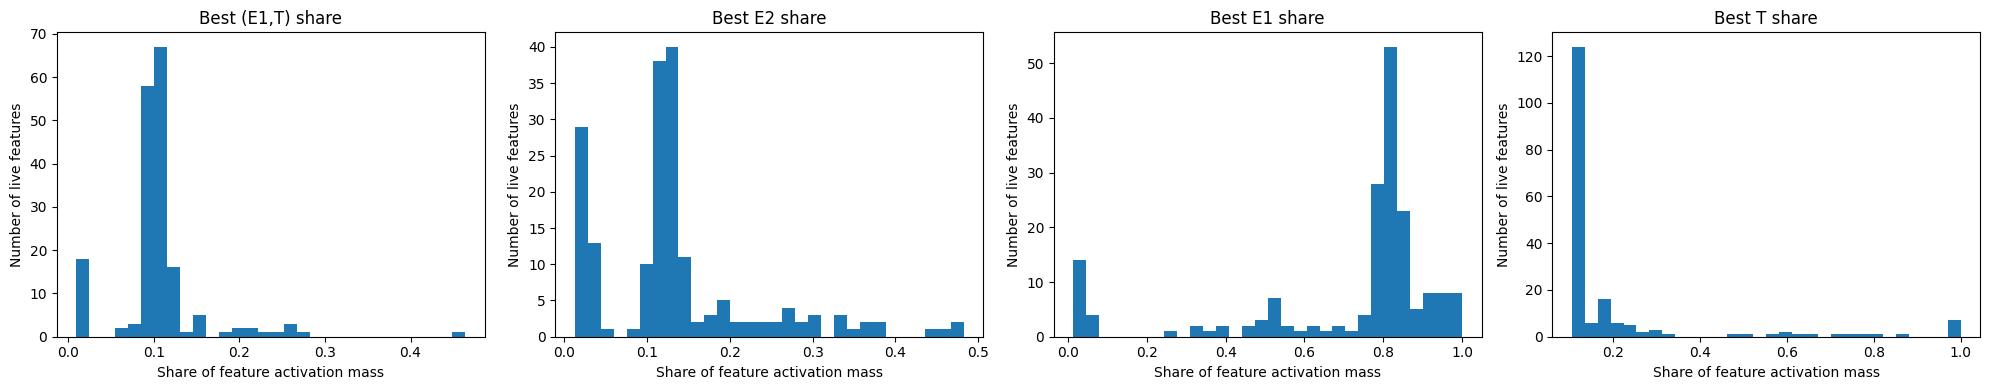

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

share_cols = [
    ("top_addr_share", "Best (E1,T) share"),
    ("top_e2_share", "Best E2 share"),
    ("top_e1_share", "Best E1 share"),
    ("top_t_share", "Best T share"),
]

for ax, (col, title) in zip(axes, share_cols):
    ax.hist(summary_df[col], bins=30)
    ax.set_title(title)
    ax.set_xlabel("Share of feature activation mass")
    ax.set_ylabel("Number of live features")

plt.tight_layout()
plt.show()


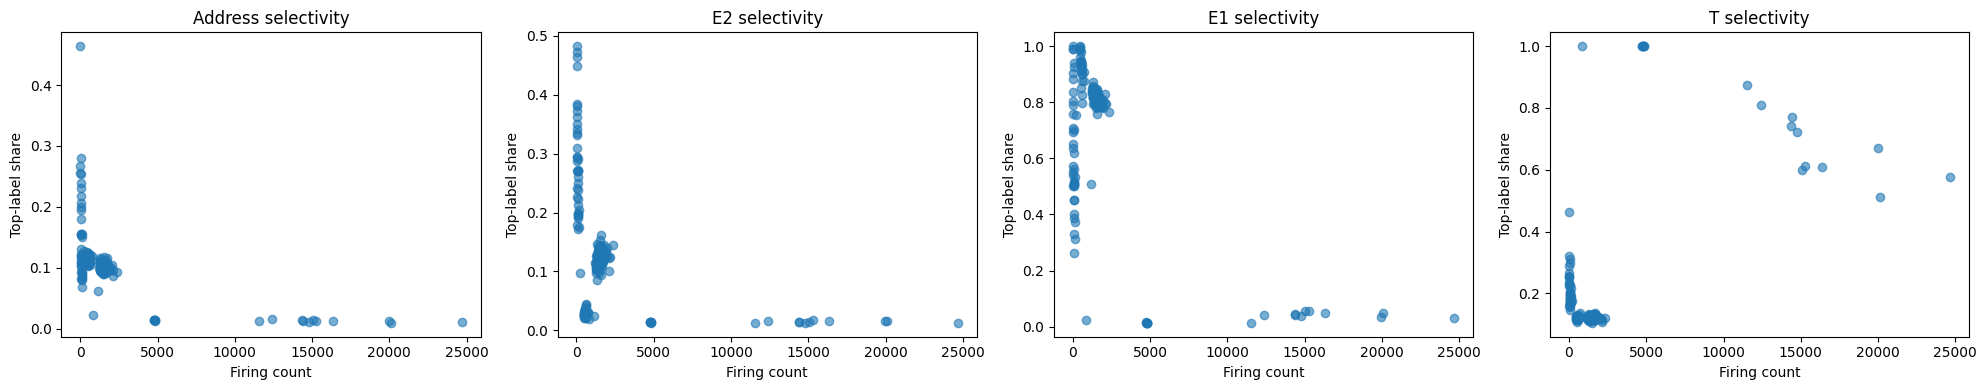

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

scatter_cols = [
    ("top_addr_share", "Address selectivity"),
    ("top_e2_share", "E2 selectivity"),
    ("top_e1_share", "E1 selectivity"),
    ("top_t_share", "T selectivity"),
]

for ax, (col, title) in zip(axes, scatter_cols):
    ax.scatter(summary_df["firing_count"], summary_df[col], alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Firing count")
    ax.set_ylabel("Top-label share")

plt.tight_layout()
plt.show()


In [29]:
# Tune these if needed, but these are reasonable first cuts
MIN_FIRING_E2 = 100
MIN_FIRING_ADDR = 10
MIN_SHARE_E2 = 0.90
MIN_SHARE_ADDR = 0.90

strong_e2_df = summary_df[
    (summary_df["firing_count"] >= MIN_FIRING_E2) & (summary_df["top_e2_share"] >= MIN_SHARE_E2)
].copy()

strong_addr_df = summary_df[
    (summary_df["firing_count"] >= MIN_FIRING_ADDR)
    & (summary_df["top_addr_share"] >= MIN_SHARE_ADDR)
].copy()

print("Strong E2-selective features:", len(strong_e2_df))
print("Strong address-selective features:", len(strong_addr_df))
print()

e2_multiplicity = (
    strong_e2_df.groupby(["top_e2", "top_e2_name"])
    .agg(
        n_features=("feature_idx", "count"),
        feature_list=("feature_idx", lambda x: list(x)),
        mean_firing_count=("firing_count", "mean"),
        mean_share=("top_e2_share", "mean"),
    )
    .sort_values(["n_features", "mean_firing_count"], ascending=[False, False])
    .reset_index()
)

addr_multiplicity = (
    strong_addr_df.groupby(["top_addr_idx", "top_addr_name"])
    .agg(
        n_features=("feature_idx", "count"),
        feature_list=("feature_idx", lambda x: list(x)),
        mean_firing_count=("firing_count", "mean"),
        mean_share=("top_addr_share", "mean"),
    )
    .sort_values(["n_features", "mean_firing_count"], ascending=[False, False])
    .reset_index()
)

print("Top E2 multiplicity")
display(e2_multiplicity)

print("Top address multiplicity")
display(addr_multiplicity)


Strong E2-selective features: 0
Strong address-selective features: 0

Top E2 multiplicity


,top_e2,top_e2_name,n_features,feature_list,mean_firing_count,mean_share


Top address multiplicity


,top_addr_idx,top_addr_name,n_features,feature_list,mean_firing_count,mean_share


In [30]:
addr_feature_mass = torch.zeros(E * T, feature_matrix.shape[1])

for row_idx, addr_idx in enumerate(addr_labels.tolist()):
    addr_feature_mass[addr_idx] += feature_matrix[row_idx]

address_rows = []

for addr_idx in range(E * T):
    vec = addr_feature_mass[addr_idx]
    total_mass = float(vec.sum().item())

    e1 = addr_idx // T
    t_rel = addr_idx % T
    t_tok = t_rel + E
    addr_name = f"{id_to_entity[e1]} | {id_to_entity[t_tok]}"

    if total_mass == 0:
        address_rows.append(
            {
                "addr_idx": addr_idx,
                "addr_name": addr_name,
                "total_mass": 0.0,
                "n_live_features": 0,
                "top_feature": None,
                "top_feature_share": 0.0,
                "features_for_50pct": None,
                "features_for_80pct": None,
            }
        )
        continue

    sorted_vals, sorted_idx = torch.sort(vec, descending=True)
    shares = sorted_vals / total_mass
    cumsum = torch.cumsum(shares, dim=0)

    n_live = int((vec > 0).sum().item())
    top_feature = int(sorted_idx[0].item())
    top_feature_share = float(shares[0].item())
    features_for_50pct = int((cumsum < 0.5).sum().item()) + 1
    features_for_80pct = int((cumsum < 0.8).sum().item()) + 1

    address_rows.append(
        {
            "addr_idx": addr_idx,
            "addr_name": addr_name,
            "total_mass": total_mass,
            "n_live_features": n_live,
            "top_feature": top_feature,
            "top_feature_share": top_feature_share,
            "features_for_50pct": features_for_50pct,
            "features_for_80pct": features_for_80pct,
        }
    )

address_df = pd.DataFrame(address_rows)
address_df.head(50)


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
0,0,Danielle | loves,15.074351,63,674,0.298555,3,5
1,1,Danielle | works with,11.343990,53,674,0.335304,2,5
2,2,Danielle | interacts with,14.715591,61,674,0.291440,2,4
3,3,Danielle | lives with,17.642384,71,674,0.297738,3,5
4,4,Danielle | has a grudge against,12.816483,58,626,0.360583,2,4
5,5,Danielle | is interested in,18.152874,71,674,0.357330,2,5
6,6,Danielle | plays with,15.528349,68,674,0.398776,2,4
7,7,Danielle | goes to school with,17.140944,57,674,0.297642,2,5
8,8,Danielle | is jealous of,12.796272,58,674,0.331773,2,5
9,9,Danielle | wants,20.067400,72,1002,0.331080,2,4


In [31]:
print("Address coverage summary")
print(
    address_df[
        ["n_live_features", "top_feature_share", "features_for_50pct", "features_for_80pct"]
    ].describe()
)


Address coverage summary
       n_live_features  top_feature_share  features_for_50pct  \
count      1000.000000        1000.000000         1000.000000   
mean         72.576000           0.371024            2.060000   
std           6.607108           0.064556            0.317018   
min          49.000000           0.192709            1.000000   
25%          69.000000           0.325902            2.000000   
50%          73.000000           0.368951            2.000000   
75%          77.000000           0.416595            2.000000   
max          91.000000           0.558225            3.000000   

       features_for_80pct  
count         1000.000000  
mean             3.449000  
std              0.809972  
min              2.000000  
25%              3.000000  
50%              3.000000  
75%              4.000000  
max              6.000000  


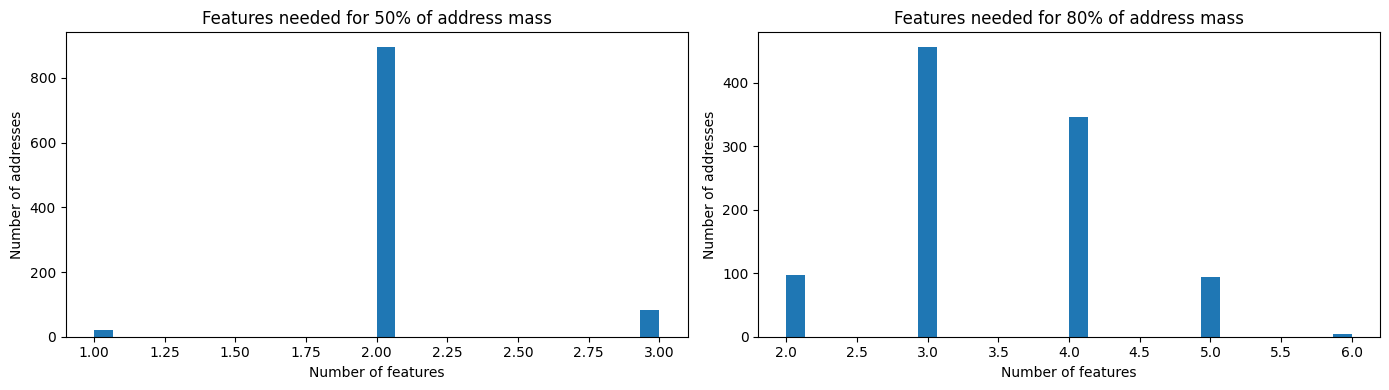

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(address_df["features_for_50pct"].dropna(), bins=30)
axes[0].set_title("Features needed for 50% of address mass")
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel("Number of addresses")

axes[1].hist(address_df["features_for_80pct"].dropna(), bins=30)
axes[1].set_title("Features needed for 80% of address mass")
axes[1].set_xlabel("Number of features")
axes[1].set_ylabel("Number of addresses")

plt.tight_layout()
plt.show()


In [33]:
print("Most compact addresses")
display(
    address_df.sort_values(
        ["features_for_80pct", "features_for_50pct", "top_feature_share"],
        ascending=[True, True, False],
    ).head(20)
)

print("Most diffuse addresses")
display(
    address_df.sort_values(
        ["features_for_80pct", "features_for_50pct", "top_feature_share"],
        ascending=[False, False, True],
    ).head(20)
)


Most compact addresses


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
284,284,Melanie | has a grudge against,10.357064,71,86,0.558225,1,2
196,196,Adam | plays with,10.929594,74,139,0.538382,1,2
428,428,Jeremy | is jealous of,12.022923,75,332,0.537228,1,2
204,204,Linda | has a grudge against,11.356541,70,364,0.531022,1,2
206,206,Linda | plays with,13.015339,74,364,0.529266,1,2
76,76,Christopher | plays with,12.945163,88,138,0.523721,1,2
208,208,Linda | is jealous of,13.733447,76,364,0.522815,1,2
514,514,Jason | has a grudge against,12.260465,68,490,0.520216,1,2
516,516,Jason | plays with,13.871433,68,490,0.518770,1,2
34,34,Jeffrey | has a grudge against,10.397315,64,578,0.516907,1,2


Most diffuse addresses


,addr_idx,addr_name,total_mass,n_live_features,top_feature,top_feature_share,features_for_50pct,features_for_80pct
397,397,Barbara | goes to school with,18.650549,66,128,0.263717,3,6
251,251,Matthew | works with,16.060163,73,317,0.264104,3,6
250,250,Matthew | loves,13.984530,60,317,0.271582,3,6
255,255,Matthew | is interested in,20.942688,81,272,0.260828,2,6
41,41,Jill | works with,17.665462,67,768,0.192709,3,5
140,140,Debra | loves,15.471541,74,856,0.224283,3,5
961,961,Wendy | works with,14.323803,66,832,0.224947,3,5
821,821,Brenda | works with,17.979239,70,220,0.226266,3,5
143,143,Debra | lives with,17.241236,76,249,0.226337,3,5
393,393,Barbara | lives with,12.531960,56,249,0.227680,3,5


In [34]:
# Relation -> feature firing counts / activation mass

num_features = feature_matrix.shape[1]

relation_feature_count = torch.zeros(T, num_features, dtype=torch.long)
relation_feature_mass = torch.zeros(T, num_features, dtype=torch.float32)
relation_row_count = torch.zeros(T, dtype=torch.long)

for row_idx in range(feature_matrix.shape[0]):
    rel = int(t_labels[row_idx].item())  # 0..9
    vals = feature_matrix[row_idx]
    active = vals > 0

    relation_feature_count[rel] += active.long()
    relation_feature_mass[rel] += vals
    relation_row_count[rel] += 1

relation_summary_rows = []

for rel in range(T):
    counts = relation_feature_count[rel]
    masses = relation_feature_mass[rel]

    top_count_vals, top_count_idx = torch.topk(counts, 15)
    top_mass_vals, top_mass_idx = torch.topk(masses, 15)

    relation_summary_rows.append(
        {
            "relation_idx": rel,
            "relation_name": id_to_entity[rel + E],
            "n_rows": int(relation_row_count[rel].item()),
            "top_features_by_count": top_count_idx.tolist(),
            "top_counts": top_count_vals.tolist(),
            "top_features_by_mass": top_mass_idx.tolist(),
            "top_masses": [float(x) for x in top_mass_vals.tolist()],
        }
    )

relation_summary_df = pd.DataFrame(relation_summary_rows)
display(relation_summary_df[["relation_name", "n_rows", "top_features_by_count", "top_counts"]])


,relation_name,n_rows,top_features_by_count,top_counts
0,loves,4717,"[822, 856, 88, 981, 894, 373, 1002, 272, 626, ...","[4717, 4671, 2430, 1878, 1866, 1455, 1257, 118..."
1,works with,4770,"[309, 373, 88, 894, 249, 272, 856, 1002, 626, ...","[4770, 4769, 2514, 1927, 1325, 1239, 1232, 121..."
2,interacts with,4754,"[981, 211, 88, 894, 249, 1002, 856, 272, 626, ...","[4754, 4754, 2444, 1905, 1378, 1282, 1275, 121..."
3,lives with,4776,"[779, 249, 88, 981, 894, 373, 626, 1002, 272, ...","[4776, 4774, 2520, 1943, 1883, 1453, 1235, 122..."
4,has a grudge against,4781,"[626, 88, 981, 894, 373, 856, 249, 1002, 128, ...","[4781, 2490, 1916, 1908, 1471, 1335, 1278, 119..."
5,is interested in,4742,"[272, 714, 88, 981, 894, 373, 249, 1002, 856, ...","[4742, 4742, 2432, 1929, 1863, 1359, 1310, 129..."
6,plays with,4818,"[88, 981, 894, 373, 249, 856, 626, 272, 128, 5...","[4818, 1956, 1900, 1455, 1352, 1316, 1247, 118..."
7,goes to school with,4814,"[548, 128, 88, 981, 373, 856, 249, 1002, 272, ...","[4814, 4814, 2558, 1950, 1458, 1327, 1319, 125..."
8,is jealous of,4767,"[894, 88, 981, 373, 856, 249, 626, 1002, 272, ...","[4767, 2467, 1879, 1462, 1314, 1268, 1257, 124..."
9,wants,4823,"[552, 1002, 894, 981, 373, 856, 249, 626, 272,...","[4823, 4823, 1943, 1894, 1472, 1362, 1262, 119..."


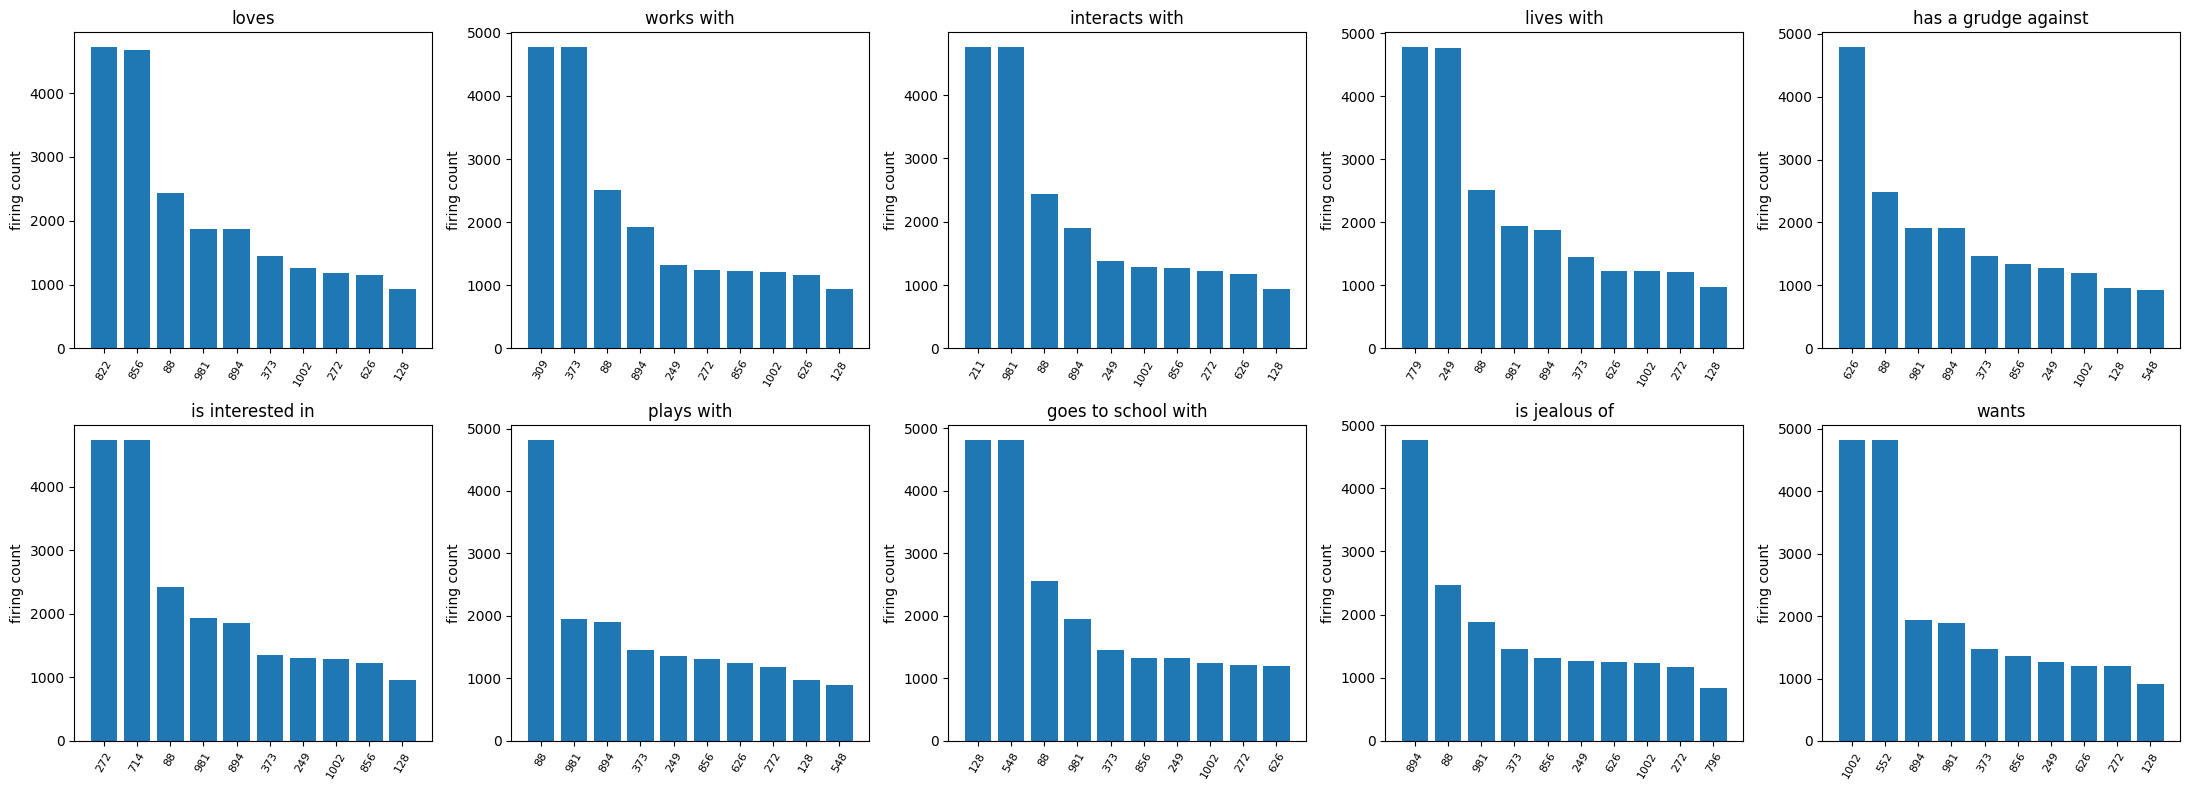

In [35]:
# Bar plots: top firing features for each relation

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for rel in range(T):
    ax = axes[rel]
    counts = relation_feature_count[rel]
    top_vals, top_idx = torch.topk(counts, 10)

    ax.bar(range(10), top_vals.tolist())
    ax.set_title(id_to_entity[rel + E])
    ax.set_xticks(range(10))
    ax.set_xticklabels(top_idx.tolist(), rotation=60, fontsize=8)
    ax.set_ylabel("firing count")

plt.tight_layout()
plt.show()


In [36]:
# computiong overlap

candidate_pairs = {
    "loves": (822, 856),
    "works with": (309, 373),
    "interacts with": (211, 981),
    "lives with": (779, 249),
    "is interested in": (714, 272),
    "goes to school with": (548, 128),
    "wants": (552, 1002),
}

pair_rows = []

for rel_name, (f_main, f_echo) in candidate_pairs.items():
    rel_idx = id_to_entity_rev[rel_name] - E
    rel_mask = t_labels == rel_idx

    main_active = feature_matrix[:, f_main] > 0
    echo_active = feature_matrix[:, f_echo] > 0

    both_active = main_active & echo_active
    either_active = main_active | echo_active

    rel_main = main_active & rel_mask
    rel_echo = echo_active & rel_mask
    rel_both = both_active & rel_mask

    pair_rows.append(
        {
            "relation": rel_name,
            "main_feature": f_main,
            "echo_feature": f_echo,
            "rows_for_relation": int(rel_mask.sum().item()),
            "main_fires_total": int(main_active.sum().item()),
            "echo_fires_total": int(echo_active.sum().item()),
            "main_fires_on_relation": int(rel_main.sum().item()),
            "echo_fires_on_relation": int(rel_echo.sum().item()),
            "both_fire_total": int(both_active.sum().item()),
            "both_fire_on_relation": int(rel_both.sum().item()),
            "main_precision_for_relation": float(
                rel_main.sum().item() / max(main_active.sum().item(), 1)
            ),
            "echo_precision_for_relation": float(
                rel_echo.sum().item() / max(echo_active.sum().item(), 1)
            ),
            "overlap_given_main": float(rel_both.sum().item() / max(rel_main.sum().item(), 1)),
            "overlap_given_echo": float(rel_both.sum().item() / max(rel_echo.sum().item(), 1)),
            "jaccard_all_rows": float(
                both_active.sum().item() / max(either_active.sum().item(), 1)
            ),
            "jaccard_on_relation_rows": float(
                rel_both.sum().item() / max((rel_main | rel_echo).sum().item(), 1)
            ),
        }
    )

pair_df = pd.DataFrame(pair_rows)
display(pair_df)


,relation,main_feature,echo_feature,rows_for_relation,main_fires_total,echo_fires_total,main_fires_on_relation,echo_fires_on_relation,both_fire_total,both_fire_on_relation,main_precision_for_relation,echo_precision_for_relation,overlap_given_main,overlap_given_echo,jaccard_all_rows,jaccard_on_relation_rows
0,loves,822,856,4717,4746,15059,4717,4671,4687,4671,0.993890,0.310180,0.990248,1.0,0.310028,0.990248
1,works with,309,373,4770,4824,16354,4770,4769,4778,4769,0.988806,0.291611,0.999790,1.0,0.291341,0.999790
2,interacts with,211,981,4754,4810,20099,4754,4754,4785,4754,0.988358,0.236529,1.000000,1.0,0.237776,1.000000
3,lives with,779,249,4776,4776,15279,4776,4774,4774,4774,1.000000,0.312455,0.999581,1.0,0.312414,0.999581
4,is interested in,714,272,4742,4742,14378,4742,4742,4742,4742,1.000000,0.329809,1.000000,1.0,0.329809,1.000000
5,goes to school with,548,128,4814,11545,12406,4814,4814,5937,4814,0.416977,0.388038,1.000000,1.0,0.329577,1.000000
6,wants,552,1002,4823,4823,14782,4823,4823,4823,4823,1.000000,0.326275,1.000000,1.0,0.326275,1.000000


In [ ]:
# entity side summary

In [38]:
# Entity -> feature firing counts / activation mass

num_features = feature_matrix.shape[1]

entity_feature_count = torch.zeros(E, num_features, dtype=torch.long)
entity_feature_mass = torch.zeros(E, num_features, dtype=torch.float32)
entity_row_count = torch.zeros(E, dtype=torch.long)

for row_idx in range(feature_matrix.shape[0]):
    ent = int(e1_labels[row_idx].item())  # 0..99
    vals = feature_matrix[row_idx]
    active = vals > 0

    entity_feature_count[ent] += active.long()
    entity_feature_mass[ent] += vals
    entity_row_count[ent] += 1

entity_summary_rows = []

for ent in range(E):
    counts = entity_feature_count[ent]
    masses = entity_feature_mass[ent]

    top_count_vals, top_count_idx = torch.topk(counts, 15)
    top_mass_vals, top_mass_idx = torch.topk(masses, 15)

    entity_summary_rows.append(
        {
            "entity_idx": ent,
            "entity_name": id_to_entity[ent],
            "n_rows": int(entity_row_count[ent].item()),
            "top_features_by_count": top_count_idx.tolist(),
            "top_counts": top_count_vals.tolist(),
            "top_features_by_mass": top_mass_idx.tolist(),
            "top_masses": [float(x) for x in top_mass_vals.tolist()],
        }
    )

entity_summary_df = pd.DataFrame(entity_summary_rows)
display(
    entity_summary_df[["entity_name", "n_rows", "top_features_by_count", "top_counts"]]
)


,entity_name,n_rows,top_features_by_count,top_counts
0,Danielle,468,"[674, 179, 32, 981, 1002, 626, 894, 856, 249, ...","[468, 466, 454, 432, 411, 407, 153, 123, 117, ..."
1,Angel,449,"[454, 626, 88, 373, 894, 856, 249, 548, 128, 8...","[449, 416, 404, 403, 173, 120, 119, 115, 89, 4..."
2,Joshua,477,"[577, 856, 894, 1002, 981, 373, 272, 626, 548,...","[477, 436, 432, 429, 167, 142, 128, 117, 97, 5..."
3,Jeffrey,494,"[578, 88, 981, 894, 373, 1002, 856, 272, 548, ...","[494, 203, 168, 156, 137, 133, 131, 131, 116, ..."
4,Jill,477,"[768, 981, 856, 88, 272, 894, 128, 548, 792, 7...","[477, 431, 430, 428, 425, 155, 123, 115, 76, 6..."
...,...,...,...,...
95,Patrick,459,"[412, 88, 894, 981, 249, 626, 373, 272, 856, 1...","[459, 418, 167, 165, 149, 133, 125, 117, 107, ..."
96,Wendy,447,"[832, 202, 626, 856, 894, 88, 981, 1002, 373, ...","[447, 443, 411, 404, 392, 174, 166, 126, 120, ..."
97,Allison,455,"[473, 128, 1002, 981, 272, 373, 249, 548, 626,...","[455, 419, 412, 165, 126, 122, 121, 121, 115, ..."
98,Tasha,485,"[612, 894, 856, 88, 981, 1002, 373, 626, 548, ...","[485, 428, 371, 206, 182, 139, 134, 128, 115, ..."


In [40]:
# For each entity, inspect its top-by-count feature:
# - coverage on the target entity
# - precision for that entity
# - top off-target entities

entity_top_feature_rows = []

for ent in range(E):
    counts = entity_feature_count[ent]
    top_feat = int(counts.argmax().item())

    fires_on_entity = int(entity_feature_count[ent, top_feat].item())
    total_fires = int(feature_firing_count[top_feat].item())
    coverage = fires_on_entity / max(int(entity_row_count[ent].item()), 1)
    precision = fires_on_entity / max(total_fires, 1)

    # where else does this feature fire?
    fires_by_entity = entity_feature_count[:, top_feat].clone()
    fires_by_entity[ent] = 0
    off_vals, off_idx = torch.topk(fires_by_entity, 5)

    entity_top_feature_rows.append(
        {
            "entity_idx": ent,
            "entity_name": id_to_entity[ent],
            "top_feature": top_feat,
            "rows_for_entity": int(entity_row_count[ent].item()),
            "fires_on_entity": fires_on_entity,
            "total_fires_of_feature": total_fires,
            "coverage_on_entity": coverage,
            "precision_for_entity": precision,
            "top_offtarget_entities": [id_to_entity[int(i)] for i in off_idx.tolist()],
            "top_offtarget_counts": off_vals.tolist(),
        }
    )

entity_top_feature_df = pd.DataFrame(entity_top_feature_rows)
display(entity_top_feature_df)


,entity_idx,entity_name,top_feature,rows_for_entity,fires_on_entity,total_fires_of_feature,coverage_on_entity,precision_for_entity,top_offtarget_entities,top_offtarget_counts
0,0,Danielle,674,468,468,1279,1.0,0.365911,"[Noah, Sherri, Robert, Matthew, Michelle]","[19, 16, 16, 14, 13]"
1,1,Angel,454,449,449,1397,1.0,0.321403,"[Lisa, Erica, Joshua, Danielle, Robert]","[20, 19, 16, 16, 15]"
2,2,Joshua,577,477,477,1360,1.0,0.350735,"[George, Matthew, Brandon, Sharon, Danielle]","[19, 19, 17, 17, 16]"
3,3,Jeffrey,578,494,494,1597,1.0,0.309330,"[Randall, Danielle, Erica, Jose, Tasha]","[27, 25, 22, 20, 20]"
4,4,Jill,768,477,477,1299,1.0,0.367206,"[Christopher, William, Matthew, Robin, Allison]","[17, 16, 14, 14, 14]"
...,...,...,...,...,...,...,...,...,...,...
95,95,Patrick,412,459,459,1334,1.0,0.344078,"[Robert, Randall, Jill, Jeffrey, Teresa]","[16, 15, 15, 15, 14]"
96,96,Wendy,832,447,447,1502,1.0,0.297603,"[Leonard, Christopher, Cynthia, Chelsea, Angela]","[24, 23, 20, 20, 19]"
97,97,Allison,473,455,455,1580,1.0,0.287975,"[Christopher, Leonard, Matthew, Michelle, Jill]","[26, 25, 25, 22, 21]"
98,98,Tasha,612,485,485,1568,1.0,0.309311,"[Joshua, Frank, Gabrielle, Jeffrey, Jessica]","[26, 24, 24, 22, 21]"


In [41]:
print("Coverage summary")
print(entity_top_feature_df["coverage_on_entity"].describe())

print("\nPrecision summary")
print(entity_top_feature_df["precision_for_entity"].describe())


Coverage summary
count    100.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: coverage_on_entity, dtype: float64

Precision summary
count    100.000000
mean       0.335329
std        0.081037
min        0.213947
25%        0.300522
50%        0.334859
75%        0.351461
max        0.915020
Name: precision_for_entity, dtype: float64


In [42]:
print("Most precise entity features")
display(
    entity_top_feature_df.sort_values(
        ["precision_for_entity", "coverage_on_entity"], ascending=[False, False]
    ).head(20)
)

print("Least precise entity features")
display(
    entity_top_feature_df.sort_values(
        ["precision_for_entity", "coverage_on_entity"], ascending=[True, False]
    ).head(20)
)


Most precise entity features


,entity_idx,entity_name,top_feature,rows_for_entity,fires_on_entity,total_fires_of_feature,coverage_on_entity,precision_for_entity,top_offtarget_entities,top_offtarget_counts
84,84,Reginald,329,463,463,506,1.0,0.915020,"[Robin, Brandon, Joshua, Jeffrey, Jill]","[37, 6, 0, 0, 0]"
52,52,Joseph,181,448,448,624,1.0,0.717949,"[Joseph, Lindsay, Cynthia, John, Jill]","[50, 50, 43, 33, 0]"
59,59,Noah,789,512,512,1283,1.0,0.399065,"[Danielle, Craig, Anthony, Eric, Anthony]","[24, 16, 14, 13, 13]"
61,61,Danielle,944,500,500,1257,1.0,0.397772,"[Janet, Jill, William, Robin, Jessica]","[19, 17, 16, 14, 14]"
71,71,Sherri,133,481,481,1215,1.0,0.395885,"[Rachael, Matthew, Keith, Sharon, Courtney]","[16, 14, 13, 13, 13]"
45,45,Jesse,178,526,526,1333,1.0,0.394599,"[Whitney, Jessica, Leslie, Andrea, Michelle]","[17, 16, 15, 15, 14]"
13,13,James,60,494,494,1291,1.0,0.382649,"[Tasha, Erica, Matthew, Andrea, Cynthia]","[18, 17, 17, 16, 14]"
68,68,Leslie,35,495,495,1301,1.0,0.380477,"[Adam, Jose, Brenda, Chelsea, Nancy]","[21, 17, 17, 16, 15]"
57,57,Jessica,361,498,498,1343,1.0,0.370812,"[Susan, Christine, Joseph, Anthony, William]","[16, 16, 15, 15, 14]"
29,29,Cassandra,143,504,504,1368,1.0,0.368421,"[Daniel, Joseph, Danielle, Cynthia, Barbara]","[20, 18, 17, 17, 16]"


Least precise entity features


,entity_idx,entity_name,top_feature,rows_for_entity,fires_on_entity,total_fires_of_feature,coverage_on_entity,precision_for_entity,top_offtarget_entities,top_offtarget_counts
93,93,Robert,55,451,451,2108,1.0,0.213947,"[Tasha, Barbara, Patricia, Christopher, Brandon]","[32, 32, 31, 29, 27]"
81,81,Jose,703,504,504,2348,1.0,0.214651,"[Danielle, Laura, Teresa, Melanie, Keith]","[36, 36, 33, 31, 31]"
66,66,Jeremy,915,478,478,2137,1.0,0.223678,"[Matthew, Daniel, Angela, Susan, Erica]","[93, 71, 69, 52, 49]"
34,34,Nicholas,827,442,442,1964,1.0,0.225051,"[Jesse, Joseph, Michelle, Tasha, Brandon]","[35, 29, 28, 27, 25]"
36,36,Maria,118,469,469,1894,1.0,0.247624,"[Matthew, Nicholas, Chelsea, Joseph, Bryan]","[42, 34, 31, 30, 29]"
94,94,Bryan,748,483,483,1864,1.0,0.259120,"[Jill, Jesse, Joseph, Gabrielle, Noah]","[66, 46, 37, 36, 35]"
43,43,Keith,69,512,512,1968,1.0,0.260163,"[Allison, Amy, Brandon, Jeffrey, Noah]","[31, 30, 30, 28, 27]"
69,69,Joseph,606,477,477,1804,1.0,0.264412,"[Tasha, Diana, Bryan, Veronica, Matthew]","[32, 26, 26, 23, 22]"
92,92,Laura,79,440,440,1663,1.0,0.264582,"[Randall, Jesse, Robert, Brandon, Christine]","[45, 45, 43, 37, 31]"
10,10,Jeffery,794,460,460,1737,1.0,0.264824,"[Kimberly, Randall, Robin, Gabrielle, Frank]","[29, 28, 28, 27, 26]"


In [43]:
import numpy as np
import matplotlib.pyplot as plt


def build_label_names():
    e1_names = [id_to_entity[i] for i in range(E)]
    t_names = [id_to_entity[i + E] for i in range(T)]
    e2_names = [id_to_entity[i] for i in range(E)]

    addr_names = []
    for e1 in range(E):
        for t_rel in range(T):
            addr_names.append(f"{id_to_entity[e1]} | {id_to_entity[t_rel + E]}")
    return e1_names, t_names, e2_names, addr_names


def analyze_label_space_best_f1(
    feature_matrix, labels, label_names, feature_firing_count, min_feature_fires=1
):
    num_labels = len(label_names)
    num_features = feature_matrix.shape[1]

    label_feature_count = torch.zeros(num_labels, num_features, dtype=torch.long)
    label_row_count = torch.zeros(num_labels, dtype=torch.long)

    for row_idx in range(feature_matrix.shape[0]):
        lab = int(labels[row_idx].item())
        vals = feature_matrix[row_idx]
        active = vals > 0

        label_feature_count[lab] += active.long()
        label_row_count[lab] += 1

    rows = []

    valid_features = feature_firing_count >= min_feature_fires

    for lab in range(num_labels):
        tp = label_feature_count[lab].float()  # fires on this label
        total_fires = feature_firing_count.float()  # fires anywhere
        total_label_rows = float(label_row_count[lab].item())

        precision = tp / torch.clamp(total_fires, min=1.0)
        recall = tp / max(total_label_rows, 1.0)
        f1 = 2 * precision * recall / torch.clamp(precision + recall, min=1e-8)

        # mask out invalid features
        f1 = f1.clone()
        f1[~valid_features] = -1

        best_feat = int(f1.argmax().item())
        best_f1 = float(f1[best_feat].item())
        best_precision = float(precision[best_feat].item())
        best_recall = float(recall[best_feat].item())

        fires_by_label = label_feature_count[:, best_feat].clone()
        fires_by_label[lab] = 0
        off_vals, off_idx = torch.topk(fires_by_label, 5)

        rows.append(
            {
                "label_idx": lab,
                "label_name": label_names[lab],
                "best_feature": best_feat,
                "f1": best_f1,
                "precision": best_precision,
                "recall": best_recall,
                "rows_for_label": int(label_row_count[lab].item()),
                "fires_on_label": int(label_feature_count[lab, best_feat].item()),
                "total_fires_of_feature": int(feature_firing_count[best_feat].item()),
                "top_offtarget_labels": [label_names[int(i)] for i in off_idx.tolist()],
                "top_offtarget_counts": off_vals.tolist(),
            }
        )

    df = pd.DataFrame(rows)
    return df, label_feature_count, label_row_count

e1_names, t_names, e2_names, addr_names = build_label_names()

e1_f1_df, e1_feature_count_f1, e1_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, e1_labels, e1_names, feature_firing_count, min_feature_fires=1
)

t_f1_df, t_feature_count_f1, t_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, t_labels, t_names, feature_firing_count, min_feature_fires=1
)

e2_f1_df, e2_feature_count_f1, e2_row_count_f1 = analyze_label_space_best_f1(
    feature_matrix, e2_labels, e2_names, feature_firing_count, min_feature_fires=1
)

print("E1 mean F1:", e1_f1_df["f1"].mean())
print("T mean F1:", t_f1_df["f1"].mean())
print("E2 mean F1:", e2_f1_df["f1"].mean())


E1 mean F1: 0.5851511752605438
T mean F1: 0.778481924533844
E2 mean F1: 0.4601717448234558


In [52]:
def analyze_label_space_best_f1(
    feature_matrix,
    labels,
    label_names,
    feature_firing_count,
    min_feature_fires=1,
    max_feature_fires=None,
):
    num_labels = len(label_names)
    num_features = feature_matrix.shape[1]

    label_feature_count = torch.zeros(num_labels, num_features, dtype=torch.long)
    label_row_count = torch.zeros(num_labels, dtype=torch.long)

    for row_idx in range(feature_matrix.shape[0]):
        lab = int(labels[row_idx].item())
        vals = feature_matrix[row_idx]
        active = vals > 0

        label_feature_count[lab] += active.long()
        label_row_count[lab] += 1

    rows = []

    valid_features = feature_firing_count >= min_feature_fires
    if max_feature_fires is not None:
        valid_features = valid_features & (feature_firing_count <= max_feature_fires)

    for lab in range(num_labels):
        tp = label_feature_count[lab].float()
        total_fires = feature_firing_count.float()
        total_label_rows = float(label_row_count[lab].item())

        precision = tp / torch.clamp(total_fires, min=1.0)
        recall = tp / max(total_label_rows, 1.0)
        f1 = 2 * precision * recall / torch.clamp(precision + recall, min=1e-8)

        f1 = f1.clone()
        f1[~valid_features] = -1

        best_feat = int(f1.argmax().item())
        best_f1 = float(f1[best_feat].item())
        best_precision = float(precision[best_feat].item())
        best_recall = float(recall[best_feat].item())

        rows.append(
            {
                "label_idx": lab,
                "label_name": label_names[lab],
                "best_feature": best_feat,
                "f1": best_f1,
                "precision": best_precision,
                "recall": best_recall,
                "rows_for_label": int(label_row_count[lab].item()),
                "fires_on_label": int(label_feature_count[lab, best_feat].item()),
                "total_fires_of_feature": int(feature_firing_count[best_feat].item()),
            }
        )

    return pd.DataFrame(rows)


addr_f1_df = analyze_label_space_best_f1(
    feature_matrix,
    addr_labels,
    addr_names,
    feature_firing_count,
)


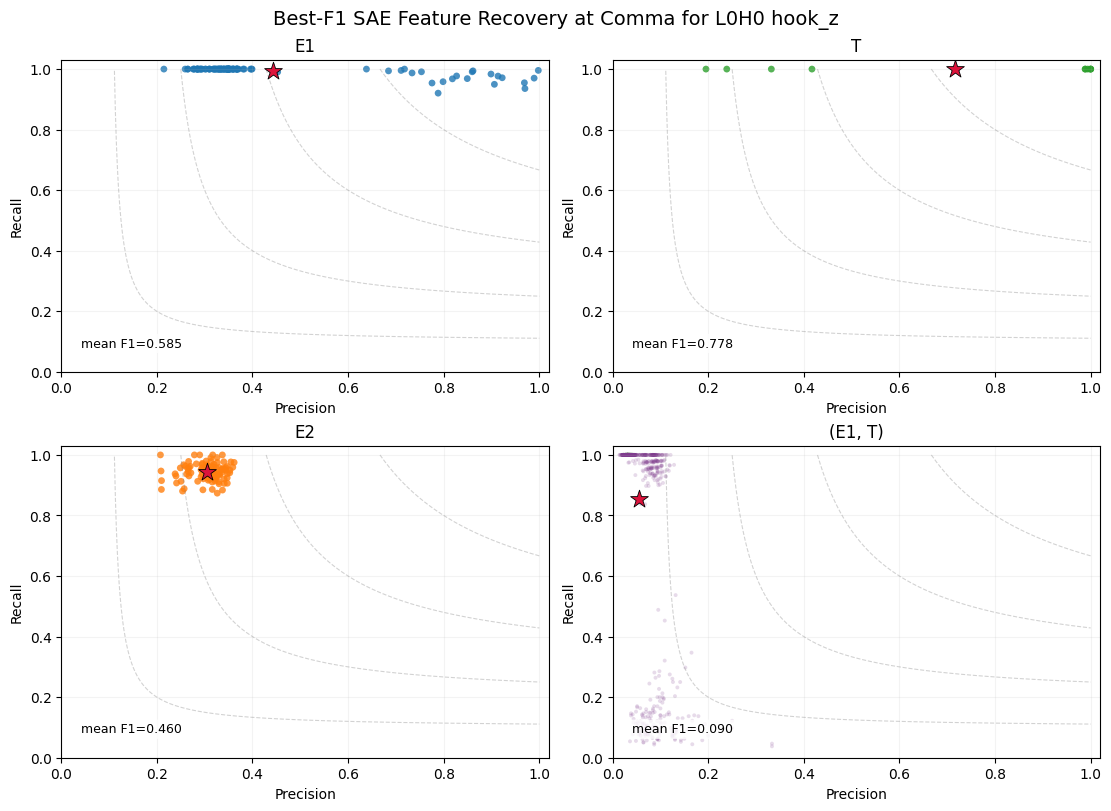

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

panels = [
    (e1_f1_df, "E1", "#1f77b4", 24, 0.80),
    (t_f1_df, "T", "#2ca02c", 24, 0.80),
    (e2_f1_df, "E2", "#ff7f0e", 24, 0.80),
    (addr_f1_df, "(E1, T)", "#7f3c8d", 8, 0.18),
]

f1_levels = [0.2, 0.4, 0.6, 0.8]

for ax, (df, title, color, size, alpha) in zip(axes.flatten(), panels):
    x = df["precision"].to_numpy()
    y = df["recall"].to_numpy()

    # iso-F1 curves
    p_grid = np.linspace(0.01, 1.0, 500)
    for f1_level in f1_levels:
        denom = 2 * p_grid - f1_level
        mask = denom > 0
        r = np.full_like(p_grid, np.nan)
        r[mask] = (f1_level * p_grid[mask]) / denom[mask]
        r[(r < 0) | (r > 1)] = np.nan
        ax.plot(p_grid, r, color="gray", linestyle="--", linewidth=0.8, alpha=0.35)

    ax.scatter(
        x,
        y,
        s=size,
        alpha=alpha,
        color=color,
        edgecolors="none",
    )

    x_mean = float(np.mean(x))
    y_mean = float(np.mean(y))
    f1_mean = float(df["f1"].mean())

    ax.scatter(
        [x_mean],
        [y_mean],
        marker="*",
        s=180,
        color="crimson",
        edgecolors="black",
        linewidths=0.6,
        zorder=5,
    )

    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.03)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Recall")
    ax.grid(alpha=0.15)

    ax.text(
        0.04,
        0.08,
        f"mean F1={f1_mean:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none"),
    )

fig.suptitle("Best-F1 SAE Feature Recovery at Comma for L0H0 hook_z", fontsize=14)
plt.savefig("s1e5_hookz_sae_feature_recovery_f1.png", dpi=300)
plt.show()


In [47]:
addr_f1_df["f1"].describe()


count    1000.000000
mean        0.032211
std         0.040182
min         0.000000
25%         0.000000
50%         0.018824
75%         0.052202
max         0.223684
Name: f1, dtype: float64